# Bài giảng 1 — Phiếu thực hành
## Nhập môn Học máy và Hồi quy tuyến tính có chính quy hóa

**TS. Phạm Văn Khánh** — Viện Công nghệ Thông tin, Viện Hàn lâm Khoa học và Công nghệ Việt Nam
18 Hoàng Quốc Việt, Cầu Giấy, Hà Nội · 0972 907 288

---

### Cách dùng phiếu này

Notebook này **không chạy được ngay**. Phần thư viện và dữ liệu đã được viết sẵn; phần còn lại là 16 nhiệm vụ để bạn tự hoàn thành.

| Ký hiệu | Nghĩa |
|:--|:--|
| 🟢 **CHO SẴN** | Ô đã viết sẵn — chạy và đọc hiểu, không cần sửa |
| ✏️ **NHIỆM VỤ** | Ô bạn phải viết. Đọc phần gợi ý phía trên trước khi gõ |
| ✅ **TỰ KIỂM TRA** | Ô đối chiếu kết quả của bạn với đáp án tham chiếu |

**Quy tắc quan trọng:** làm **tuần tự từ trên xuống**. Nhiệm vụ sau dùng biến do nhiệm vụ trước tạo ra, nên bỏ qua một nhiệm vụ sẽ làm hỏng phần còn lại.

Ô tự kiểm tra dùng `assert`. Nếu code đúng, ô in ra dòng bắt đầu bằng ✅. Nếu sai, Python báo `AssertionError` kèm gợi ý — đó là thông tin có ích, không phải sự cố.

Mọi số liệu tham chiếu đều tái lập được với `random_state = 42`. Nếu bạn đổi seed, các ô kiểm tra sẽ báo sai — đó là hành vi đúng.

Tài liệu lý thuyết đi kèm: `Bai_giang_01_Nhap_mon_ML_va_Hoi_quy_tuyen_tinh.docx`. Số hiệu mục được ghi trong từng phần để bạn tra cứu.

---
# Phần chuẩn bị — 🟢 CHO SẴN

Ba ô dưới đây đã hoàn chỉnh. Chạy chúng trước khi làm bất kỳ nhiệm vụ nào.

In [22]:
# 🟢 CHO SẴN — thư viện và cấu hình
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy import stats

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (train_test_split, KFold, cross_val_score,
                                     GridSearchCV, learning_curve)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.dummy import DummyRegressor

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.3,
    "font.family": "DejaVu Sans",     # phông hỗ trợ tiếng Việt, có sẵn trên Colab
})

import sklearn
print("numpy", np.__version__, "| pandas", pd.__version__, "| sklearn", sklearn.__version__)

numpy 2.1.3 | pandas 2.2.3 | sklearn 1.6.1


In [23]:
# 🟢 CHO SẴN — tải dữ liệu California Housing (Điều tra dân số Hoa Kỳ 1990)
URL = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
housing = pd.read_csv(URL)

print("Kích thước:", housing.shape)
housing.head()

Kích thước: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [24]:
# 🟢 CHO SẴN — khảo sát nhanh chất lượng dữ liệu
print(housing.info(), "\n")
display(housing.describe().T[["count", "mean", "std", "min", "50%", "max"]].round(2))

print("Số quan sát có giá đúng bằng 500.001 :", (housing.median_house_value >= 500001).sum())
print("Số giá trị thiếu ở total_bedrooms    :", housing.total_bedrooms.isna().sum())
print("Phân bố ocean_proximity              :", housing.ocean_proximity.value_counts().to_dict())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None 



,count,mean,std,min,50%,max
longitude,20640.0,-119.57,2.00,-124.35,-118.49,-114.31
latitude,20640.0,35.63,2.14,32.54,34.26,41.95
housing_median_age,20640.0,28.64,12.59,1.00,29.00,52.00
total_rooms,20640.0,2635.76,2181.62,2.00,2127.00,39320.00
total_bedrooms,20433.0,537.87,421.39,1.00,435.00,6445.00
population,20640.0,1425.48,1132.46,3.00,1166.00,35682.00
households,20640.0,499.54,382.33,1.00,409.00,6082.00
median_income,20640.0,3.87,1.90,0.50,3.53,15.00
median_house_value,20640.0,206855.82,115395.62,14999.00,179700.00,500001.00


Số quan sát có giá đúng bằng 500.001 : 965
Số giá trị thiếu ở total_bedrooms    : 207
Phân bố ocean_proximity              : {'<1H OCEAN': 9136, 'INLAND': 6551, 'NEAR OCEAN': 2658, 'NEAR BAY': 2290, 'ISLAND': 5}


**Ba vấn đề chất lượng đã lộ ra ngay từ đây** — bạn sẽ xử lý chúng ở Nhiệm vụ 7:

1. `total_bedrooms` thiếu 207 giá trị.
2. `median_house_value` có giá trị lớn nhất **đúng bằng 500.001** — dấu hiệu dữ liệu bị chặn (censored), không phải giá thật.
3. `ocean_proximity` là biến định tính, và mức `ISLAND` chỉ có 5 quan sát.

---
# Lab 1 — Phân rã độ chệch – phương sai
*Tham chiếu: Định lý 1.1, mục 1.6*

Định lý phát biểu rằng sai số dự báo kỳ vọng tách thành ba phần:

$$\mathbb{E}\big[(y_0-\hat{f}_S(x_0))^2\big] = \underbrace{\big(\mathbb{E}_S[\hat f_S(x_0)]-f(x_0)\big)^2}_{\text{độ chệch}^2} + \underbrace{\operatorname{Var}_S(\hat f_S(x_0))}_{\text{phương sai}} + \underbrace{\sigma^2}_{\text{nhiễu}}$$

Kỳ vọng $\mathbb{E}_S$ lấy theo **tính ngẫu nhiên của tập huấn luyện**. Ngoài đời ta chỉ có một tập huấn luyện nên không tính được — nhưng trong mô phỏng ta sinh bao nhiêu tập cũng được.

### ✏️ Nhiệm vụ 1 — Ước lượng độ chệch và phương sai bằng Monte Carlo

Viết hàm `simulate_bias_variance(degree, n_sim=200, n_train=25, sigma=0.35)`.

**Thuật toán:**
1. Lặp `n_sim` lần. Ở lần thứ `s`, dùng `rng = np.random.default_rng(s)` để có thể tái lập.
2. Mỗi lần: sinh `n_train` điểm `xs` đều trên $[-3, 3]$, và `ys = f_true(xs) + nhiễu chuẩn(0, sigma)`.
3. Khớp `make_pipeline(PolynomialFeatures(degree), LinearRegression())` trên tập đó.
4. Dự báo trên lưới cố định `X_GRID` (đã cho sẵn), lưu vào hàng `s` của ma trận `preds`.
5. Sau vòng lặp: `bias2` = trung bình bình phương sai lệch giữa **dự báo trung bình theo các tập** và `f_true(X_GRID)`; `var` = trung bình của phương sai theo cột.

**Gợi ý API:** `preds.mean(axis=0)`, `preds.var(axis=0)`, `rng.uniform(-3, 3, n)`, `rng.normal(0, sigma, n)`.

**Cạm bẫy thường gặp:** lấy phương sai theo sai trục. Phương sai cần tính **giữa các tập huấn luyện** tại mỗi điểm $x_0$, tức theo `axis=0`.

In [25]:
# 🟢 CHO SẴN — hàm thật và lưới điểm kiểm tra
def f_true(x):
    """Hàm sinh dữ liệu thật (trong thực tế ta không biết hàm này)."""
    return np.sin(x) + 0.3 * x

X_GRID = np.linspace(-3, 3, 120)

In [26]:
# ✏️ NHIỆM VỤ 1
def simulate_bias_variance(degree, n_sim=200, n_train=25, sigma=0.35):
    """Trả về (bias2, var) ước lượng bằng mô phỏng Monte Carlo."""
    preds = np.empty((n_sim, len(X_GRID)))

    for s in range(n_sim):
        rng = np.random.default_rng(s)
        # TODO 1. sinh xs (n_train điểm đều trên [-3, 3]) và ys = f_true(xs) + nhiễu
        xs = rng.uniform(-3, 3, n_train)
        ys = f_true(xs) + rng.normal(0, sigma, n_train)
        # TODO 2. khớp mô hình đa thức bậc `degree`
        model = make_pipeline(
            PolynomialFeatures(degree),
            LinearRegression()
        )
        # TODO 3. preds[s] = dự báo của mô hình trên X_GRID
        model.fit(xs.reshape(-1, 1), ys)
        preds[s] = model.predict(X_GRID.reshape(-1, 1))
    mean_pred = preds.mean(axis=0)

    # TODO 4. bias2 và var từ ma trận preds
    bias2 = np.mean((mean_pred - f_true(X_GRID)) ** 2)
    var = np.mean(preds.var(axis=0))
    return bias2, var

In [9]:
# ✅ TỰ KIỂM TRA — Nhiệm vụ 1
b1, v1 = simulate_bias_variance(1)
b3, v3 = simulate_bias_variance(3)
assert abs(b1 - 0.1703) < 2e-3, f"bias² bậc 1 nên ≈ 0.1703, bạn ra {b1:.4f}"
assert abs(v1 - 0.0283) < 2e-3, f"phương sai bậc 1 nên ≈ 0.0283, bạn ra {v1:.4f}"
assert abs(b3 - 0.0035) < 2e-3, f"bias² bậc 3 nên ≈ 0.0035, bạn ra {b3:.4f}"
assert b3 < b1 / 10, "độ chệch phải giảm mạnh từ bậc 1 sang bậc 3 — kiểm tra lại mean_pred"
print(f"✅ Bậc 1: bias²={b1:.4f}, var={v1:.4f}   |   Bậc 3: bias²={b3:.4f}, var={v3:.4f}")

✅ Bậc 1: bias²=0.1703, var=0.0283   |   Bậc 3: bias²=0.0035, var=0.0251


### ✏️ Nhiệm vụ 2 — Vẽ đường cong đánh đổi và tìm bậc tối ưu

Chạy `simulate_bias_variance` cho các bậc từ 1 đến 12, lưu kết quả, rồi:

1. Tạo `DataFrame` với các cột `bậc`, `bias²`, `phương sai`, `tổng` (tổng = bias² + var + σ²).
2. Vẽ cả ba đường trên **thang log** cho trục y, kèm đường ngang tại $\sigma^2 = 0.1225$.
3. Gán `best_degree` = bậc có tổng nhỏ nhất.

**Gợi ý:** `ax.set_yscale("log")`, `ax.axhline(...)`, `int(np.argmin(totals)) + 1`.

**Bạn nên thấy:** phương sai tăng đơn điệu, tổng có dạng chữ U, và không đường nào xuống dưới sàn nhiễu $\sigma^2 = 0{,}1225$.

**Một chi tiết đáng dừng lại.** Lý thuyết nói độ chệch giảm khi lớp hàm giàu lên, và điều đó đúng từ bậc 1 đến khoảng bậc 5 (0,1703 → 0,0007). Nhưng ở bậc 8 trở lên, bias² **đo được lại tăng** — bậc 12 cho tới 12,6.

Đây không phải lỗi cài đặt. Với 25 điểm huấn luyện, ma trận Vandermonde bậc 12 có điều kiện cực xấu; các fit dao động dữ dội đến mức **ngay cả trung bình của chúng** cũng lệch xa hàm thật. Nói cách khác, phương sai lớn tới mức làm hỏng luôn ước lượng độ chệch. Hãy ghi nhớ: "độ chệch giảm đơn điệu" là phát biểu về lớp hàm lý tưởng, không phải về ước lượng thực nghiệm trên mẫu hữu hạn.

,bậc,bias²,phương sai,tổng
0,1,0.1703,0.0283,0.3211
1,2,0.1714,0.0535,0.3474
2,3,0.0035,0.0251,0.1511
3,4,0.0036,0.0417,0.1678
4,5,0.0007,0.0730,0.1962
5,6,0.0009,0.1289,0.2522
6,7,0.0031,0.6476,0.7732
7,8,0.0048,3.5500,3.6773
8,9,0.0899,9.0749,9.2873
9,10,1.0885,165.4342,166.6452


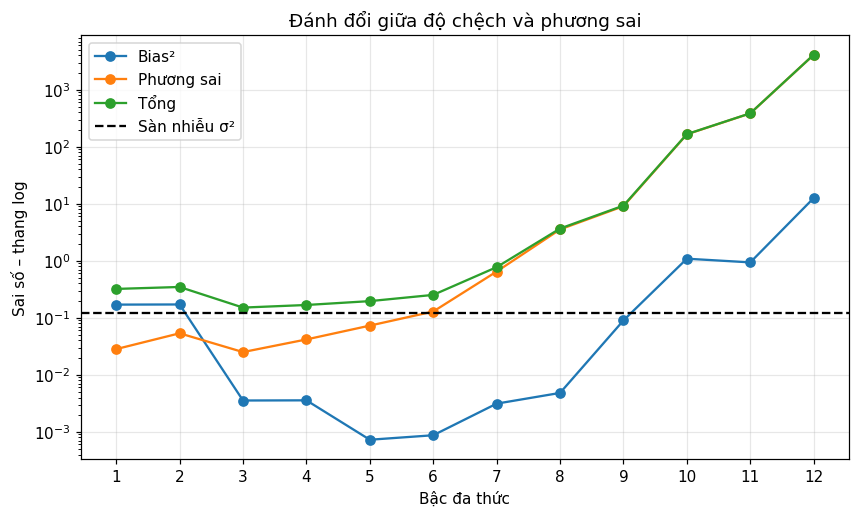

Bậc tối ưu: 3


In [10]:
# ✏️ NHIỆM VỤ 2
SIGMA = 0.35
degrees = range(1, 13)
bias2_list, var_list, total_list = [], [], []

# TODO 1. vòng lặp qua degrees, gọi simulate_bias_variance, nối vào ba danh sách
for degree in degrees:
    bias2, var = simulate_bias_variance(degree)

    bias2_list.append(bias2)
    var_list.append(var)
    total_list.append(bias2 + var + SIGMA**2)
# TODO 2. tạo DataFrame kết quả và hiển thị
result_df = pd.DataFrame({
    "bậc": list(degrees),
    "bias²": bias2_list,
    "phương sai": var_list,
    "tổng": total_list
})
# TODO 3. vẽ ba đường + đường sàn nhiễu, trục y thang log
display(result_df.round(4))

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(result_df["bậc"], result_df["bias²"],
        marker="o", label="Bias²")

ax.plot(result_df["bậc"], result_df["phương sai"],
        marker="o", label="Phương sai")

ax.plot(result_df["bậc"], result_df["tổng"],
        marker="o", label="Tổng")

ax.axhline(
    SIGMA**2,
    color="black",
    linestyle="--",
    label="Sàn nhiễu σ²"
)

ax.set_yscale("log")
ax.set_xlabel("Bậc đa thức")
ax.set_ylabel("Sai số – thang log")
ax.set_title("Đánh đổi giữa độ chệch và phương sai")
ax.set_xticks(list(degrees))
ax.legend()

plt.show()
best_degree = int(np.argmin(total_list)) + 1
print("Bậc tối ưu:", best_degree)

In [11]:
# ✅ TỰ KIỂM TRA — Nhiệm vụ 2
assert len(bias2_list) == 12 and len(var_list) == 12, "phải có đủ 12 bậc"
assert best_degree == 3, f"bậc tối ưu nên là 3, bạn ra {best_degree}"
assert bias2_list[2] < bias2_list[0] / 10, "độ chệch phải giảm mạnh từ bậc 1 đến bậc 3"
assert var_list[-1] > var_list[0] * 100, "phương sai phải bùng nổ ở bậc cao"
assert bias2_list[-1] > bias2_list[4], "ở bậc rất cao, bias² đo được TĂNG trở lại — xem ghi chú bên dưới"
assert min(total_list) > SIGMA**2, "tổng không bao giờ xuống dưới sàn nhiễu σ² = 0.1225"
print(f"✅ Bậc tối ưu = {best_degree}. Phương sai tăng {var_list[-1]/var_list[0]:,.0f} lần từ bậc 1 đến bậc 12.")
print(f"   bias²: bậc 1 = {bias2_list[0]:.4f} → bậc 5 = {bias2_list[4]:.4f} → bậc 12 = {bias2_list[-1]:.4f}")

✅ Bậc tối ưu = 3. Phương sai tăng 145,174 lần từ bậc 1 đến bậc 12.
   bias²: bậc 1 = 0.1703 → bậc 5 = 0.0007 → bậc 12 = 12.6082


---
# Lab 2 — Cài đặt OLS từ đầu và ổn định số học
*Tham chiếu: mục 2.3 và 2.7*

Nghiệm chuẩn tắc $\hat{\boldsymbol\beta} = (\mathbf X^\top\mathbf X)^{-1}\mathbf X^\top\mathbf y$ đúng về toán học nhưng nguy hiểm về số học: số điều kiện bị bình phương, $\kappa(\mathbf X^\top\mathbf X) = \kappa(\mathbf X)^2$.

### ✏️ Nhiệm vụ 3 — Bốn cách giải cùng một bài toán

Cài đặt bốn hàm, mỗi hàm nhận `(X, y)` và trả về vectơ hệ số:

| Hàm | Cách làm | Gợi ý API |
|:--|:--|:--|
| `ols_inv` | Nghịch đảo tường minh — **cách sai trong thực hành** | `np.linalg.inv` |
| `ols_cholesky` | Phân tích Cholesky của $\mathbf X^\top\mathbf X$ | `scipy.linalg.cho_factor`, `cho_solve` |
| `ols_qr` | $\mathbf X = \mathbf{QR}$, rồi giải $\mathbf R\hat{\boldsymbol\beta} = \mathbf Q^\top\mathbf y$ | `np.linalg.qr`, `np.linalg.solve` |
| `ols_svd` | Bình phương tối thiểu qua SVD | `np.linalg.lstsq(..., rcond=None)[0]` |

Kiểm chứng trên Ví dụ 2.1 của tài liệu: $x = (1,2,3,4)$, $y = (2,3,5,4)$ — nghiệm tính tay là $(1{,}5;\ 0{,}8)$.

In [17]:
# ✏️ NHIỆM VỤ 3
from scipy.linalg import cho_factor, cho_solve

def ols_inv(X, y):
    """Cách SAI trong thực hành — chỉ dùng để so sánh."""
   # raise NotImplementedError
    XtX = X.T @ X
    Xty = X.T @ y

    return np.linalg.inv(XtX) @ Xty

def ols_cholesky(X, y):
    #raise NotImplementedError
    XtX = X.T @ X
    Xty = X.T @ y

    factor = cho_factor(XtX)
    return cho_solve(factor, Xty)

def ols_qr(X, y):
   # raise NotImplementedError
    Q, R = np.linalg.qr(X)

    return np.linalg.solve(R, Q.T @ y)

def ols_svd(X, y):
   # raise NotImplementedError
    return np.linalg.lstsq(X, y, rcond=None)[0]


# Dữ liệu Ví dụ 2.1
x_ex = np.array([1., 2., 3., 4.])
y_ex = np.array([2., 3., 5., 4.])
X_ex = np.c_[np.ones(4), x_ex]          # thêm cột hằng số cho hệ số chặn
methods = [
    ("inv", ols_inv),
    ("cholesky", ols_cholesky),
    ("qr", ols_qr),
    ("svd", ols_svd)
]
for name, fn in [("inv", ols_inv), ("cholesky", ols_cholesky), ("qr", ols_qr), ("svd", ols_svd)]:
    print(f"{name:10s} beta = {np.round(fn(X_ex, y_ex), 6)}")

inv        beta = [1.5 0.8]
cholesky   beta = [1.5 0.8]
qr         beta = [1.5 0.8]
svd        beta = [1.5 0.8]


In [18]:
# ✅ TỰ KIỂM TRA — Nhiệm vụ 3
target = np.array([1.5, 0.8])
for name, fn in [("inv", ols_inv), ("cholesky", ols_cholesky), ("qr", ols_qr), ("svd", ols_svd)]:
    got = fn(X_ex, y_ex)
    assert np.allclose(got, target, atol=1e-8), f"{name} ra {got}, phải là {target}"
res = y_ex - X_ex @ target
assert abs(res.sum()) < 1e-10, "tổng phần dư phải bằng 0 (vì mô hình có hệ số chặn)"
assert abs((x_ex * res).sum()) < 1e-10, "phần dư phải trực giao với đặc trưng x"
print(f"✅ Cả bốn phương pháp cho (1.5, 0.8). RSS = {res @ res:.2f}, R² = {1 - (res@res)/((y_ex-y_ex.mean())@(y_ex-y_ex.mean())):.2f}")

✅ Cả bốn phương pháp cho (1.5, 0.8). RSS = 1.80, R² = 0.64


### ✏️ Nhiệm vụ 4 — Ma trận điều kiện xấu

Hàm dựng ma trận có số điều kiện đặt trước đã cho sẵn. Việc của bạn:

1. Sinh `X_ill` với $\kappa = 10^9$, đặt `beta_true = np.ones(p)` và `y_ill = X_ill @ beta_true` — **không thêm nhiễu**, để mọi sai số thu được đều là sai số làm tròn của máy.
2. In $\kappa(\mathbf X)$ và $\kappa(\mathbf X^\top\mathbf X)$ để thấy hiện tượng bình phương.
3. Với mỗi phương pháp, tính `np.linalg.norm(beta_hat - beta_true)` và đưa vào một `DataFrame`.

**Bạn nên thấy:** `qr` và `svd` sai số cỡ $10^{-9}$; `inv` và `cholesky` sai số cỡ đơn vị — chênh nhau khoảng **chín bậc độ lớn**.

In [19]:
# 🟢 CHO SẴN — dựng ma trận có số điều kiện đặt trước
def make_ill_conditioned(n=200, p=12, kappa=1e9, seed=0):
    rng = np.random.default_rng(seed)
    U, _ = np.linalg.qr(rng.normal(size=(n, p)))
    V, _ = np.linalg.qr(rng.normal(size=(p, p)))
    s = np.logspace(0, -np.log10(kappa), p)     # giá trị kỳ dị trải từ 1 xuống 1/kappa
    return U @ np.diag(s) @ V.T

In [20]:
# ✏️ NHIỆM VỤ 4
X_ill = make_ill_conditioned(n=200,p=12,kappa=1e9,seed=0)
beta_true = np.ones(X_ill.shape[1])
y_ill = X_ill @ beta_true

# TODO in kappa(X) và kappa(X'X)
print("kappa(X)    =", f"{np.linalg.cond(X_ill):.3e}")
print("kappa(X'X)  =", f"{np.linalg.cond(X_ill.T @ X_ill):.3e}")
rows = []

# TODO với mỗi phương pháp: tính sai số chuẩn Euclid so với beta_true, nối vào rows
methods = [
    ("inv", ols_inv),
    ("cholesky", ols_cholesky),
    ("qr", ols_qr),
    ("svd", ols_svd)
]
for name, fn in methods:
    try:
        beta_hat = fn(X_ill, y_ill)
        error = np.linalg.norm(beta_hat - beta_true)
    except np.linalg.LinAlgError:
        # Cholesky có thể thất bại nếu sai số số học làm X'X
        # không còn được xem là xác định dương.
        error = np.inf

    rows.append((name, error))

error_df = pd.DataFrame(
    rows,
    columns=["phương pháp", "sai số"]
)

display(error_df)
pd.DataFrame(rows, columns=["phương pháp", "sai số"])

kappa(X)    = 1.000e+09
kappa(X'X)  = 3.717e+16


,phương pháp,sai số
0,inv,6.054521e+00
1,cholesky,8.649003e+00
2,qr,6.369457e-09
3,svd,8.314204e-09


,phương pháp,sai số
0,inv,6.054521e+00
1,cholesky,8.649003e+00
2,qr,6.369457e-09
3,svd,8.314204e-09


In [21]:
# ✅ TỰ KIỂM TRA — Nhiệm vụ 4
err = {n: v for n, v in rows}
assert err["qr"] < 1e-6, f"QR phải rất chính xác, bạn ra {err['qr']:.2e}"
assert err["svd"] < 1e-6, f"SVD phải rất chính xác, bạn ra {err['svd']:.2e}"
assert err["inv"] > err["qr"] * 1e4, "phương pháp nghịch đảo phải TỆ hơn QR nhiều bậc độ lớn"
print(f"✅ QR: {err['qr']:.2e}   SVD: {err['svd']:.2e}   inv: {err['inv']:.2e}")
print(f"   Chênh lệch: {err['inv']/err['qr']:.0e} lần — toàn bộ là sai số làm tròn.")

✅ QR: 6.37e-09   SVD: 8.31e-09   inv: 6.05e+00
   Chênh lệch: 1e+09 lần — toàn bộ là sai số làm tròn.


---
# Lab 3 — Hạ gradient và vai trò của chuẩn hóa
*Tham chiếu: mục 2.8*

Với $J(\boldsymbol\beta)=\frac1n\|\mathbf y-\mathbf X\boldsymbol\beta\|^2$, gradient là $\nabla J = \frac{2}{n}\mathbf X^\top(\mathbf X\boldsymbol\beta-\mathbf y)$.

### ✏️ Nhiệm vụ 5 — Cài đặt hạ gradient theo lô

Viết `gradient_descent(X, y, eta=0.05, n_iter=200, record=False)`:

* Khởi tạo $\boldsymbol\beta = \mathbf 0$.
* Mỗi vòng: tính phần dư, giá trị hàm mục tiêu $J$, gradient, rồi cập nhật $\boldsymbol\beta \leftarrow \boldsymbol\beta - \eta\nabla J$.
* Nếu `record=True`, trả về `(beta, history)` với `history` là mảng mỗi dòng gồm `[t, *beta, J, *grad]` **ghi trước khi cập nhật**; ngược lại chỉ trả về `beta`.

Sau đó tái lập bảng lặp của Ví dụ 2.2 (7 dòng đầu, $\eta = 0{,}05$).

**Bạn nên thấy:** $J$ tụt từ 13,50 xuống 0,996 chỉ sau một bước rồi gần như đứng yên; sau 200 vòng vẫn chưa tới nghiệm đóng $(1{,}5;\ 0{,}8)$.

In [27]:
def gradient_descent(X, y, eta=0.05, n_iter=200, record=False):
    n = len(y)
    beta = np.zeros(X.shape[1])
    history = []
    for t in range(n_iter):
        # TODO 1. resid = X @ beta - y
        resid = X @ beta - y
        # TODO 2. J = trung bình bình phương phần dư
        J = np.mean(resid ** 2)
        # TODO 3. grad = (2/n) * X.T @ resid
        grad = (2 / n) * X.T @ resid
        # TODO 4. nếu record: history.append([t, *beta, J, *grad])   (GHI TRƯỚC khi cập nhật)
        if record:
            history.append([t, *beta, J, *grad])
        # TODO 5. cập nhật beta
        beta = beta - eta * grad
    return (beta, np.array(history)) if record else beta

beta_gd, hist = gradient_descent(X_ex, y_ex, eta=0.05, n_iter=7, record=True)
pd.DataFrame(hist, columns=["t", "beta0", "beta1", "J", "dJ/db0", "dJ/db1"]).round(4)

,t,beta0,beta1,J,dJ/db0,dJ/db1
0,0.0,0.0000,0.0000,13.5000,-7.0000,-19.5000
1,1.0,0.3500,0.9750,0.9959,-1.4250,-3.1250
2,2.0,0.4212,1.1312,0.6500,-0.5012,-0.4250
3,3.0,0.4463,1.1525,0.6351,-0.3449,0.0191
4,4.0,0.4636,1.1515,0.6293,-0.3152,0.0910
5,5.0,0.4793,1.1470,0.6240,-0.3064,0.1015
6,6.0,0.4946,1.1419,0.6188,-0.3011,0.1020


In [28]:
# ✅ TỰ KIỂM TRA — Nhiệm vụ 5
assert hist.shape == (7, 6), f"history phải có dạng (7, 6), bạn ra {hist.shape}"
assert abs(hist[0, 3] - 13.5) < 1e-6, f"J tại t=0 phải là 13.5, bạn ra {hist[0,3]:.4f}"
assert abs(hist[1, 3] - 0.9959) < 1e-3, f"J tại t=1 phải ≈ 0.9959, bạn ra {hist[1,3]:.4f}"
assert abs(hist[0, 4] + 7.0) < 1e-6, "gradient theo beta0 tại t=0 phải là -7.0 (ghi TRƯỚC khi cập nhật)"

b200 = gradient_descent(X_ex, y_ex, 0.05, 200)
assert np.allclose(b200, [1.4461, 0.8183], atol=2e-3), f"sau 200 vòng nên ≈ (1.446, 0.818), bạn ra {b200}"
b_div = gradient_descent(X_ex, y_ex, 0.30, 12)
assert np.abs(b_div).max() > 1e5, "với eta = 0.30 thuật toán phải PHÂN KỲ"
print(f"✅ 200 vòng: {np.round(b200, 4)} vs nghiệm đóng (1.5, 0.8)")
print(f"   eta = 0.30 phân kỳ: beta0 ≈ {b_div[0]:.2e}")

✅ 200 vòng: [1.4461 0.8183] vs nghiệm đóng (1.5, 0.8)
   eta = 0.30 phân kỳ: beta0 ≈ -6.91e+06


### ✏️ Nhiệm vụ 6 — Chuẩn hóa thay đổi mọi thứ

1. Chuẩn hóa `x_ex` thành `x_std = (x - mean) / std`, dựng `X_std` có cột hằng số.
2. So sánh `np.linalg.cond` của $\mathbf X^\top\mathbf X$ trước và sau chuẩn hóa.
3. Chạy hạ gradient trên dữ liệu chuẩn hóa với $\eta = 0{,}1$, chỉ **30 vòng**, so với nghiệm đóng.
4. Vẽ hai đồ thị cạnh nhau: $J$ theo vòng lặp cho $\eta \in \{0{,}001;\ 0{,}01;\ 0{,}05;\ 0{,}1\}$ — một cho dữ liệu thô, một cho dữ liệu chuẩn hóa (trục y thang log).

**Bạn nên thấy:** $\kappa$ đi từ 55,8 xuống đúng 1,0, và 30 vòng trên dữ liệu chuẩn hóa cho độ chính xác mà 200 vòng trên dữ liệu thô không đạt được.

kappa(X'X) (dữ liệu thô): 55.78
kappa(X'X) (dữ liệu chuẩn hóa): 1.00

Nghiệm GD (30 vòng, eta=0.1, chuẩn hóa): [3.4957 0.8933]
Nghiệm đóng (OLS QR, chuẩn hóa): [3.5    0.8944]


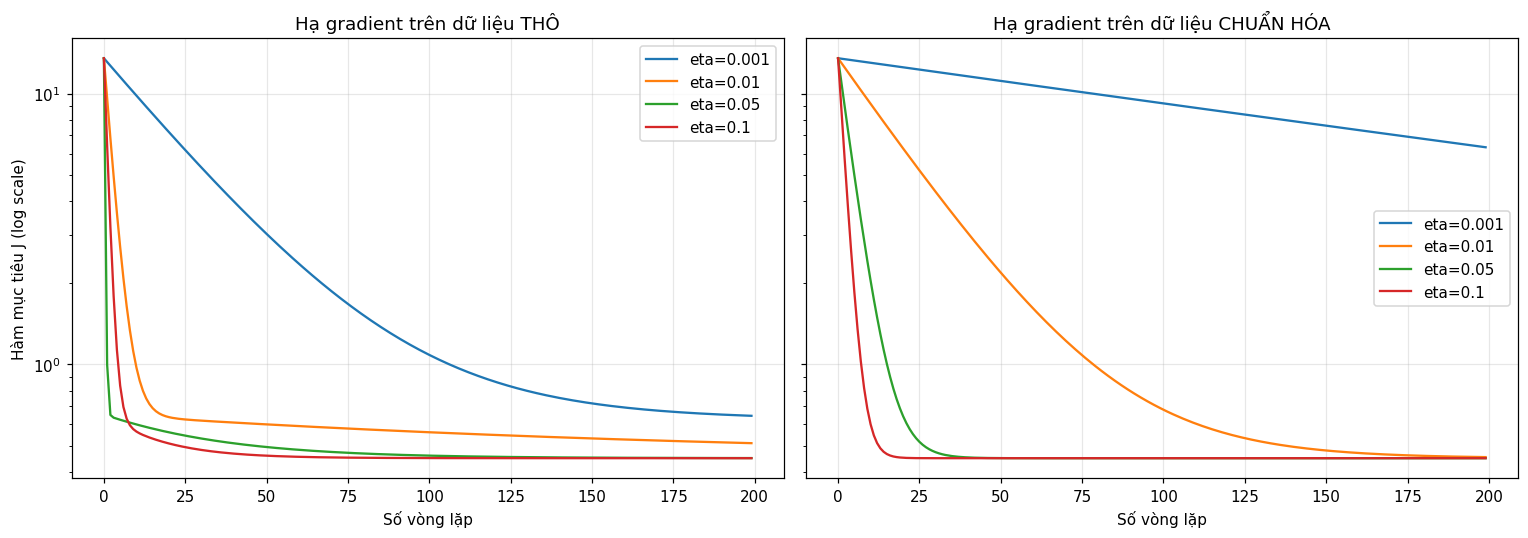

In [29]:
# ✏️ NHIỆM VỤ 6
# 1. Chuẩn hóa x_ex thành x_std và dựng X_std
x_mean = x_ex.mean()
x_std_dev = x_ex.std()
x_std = (x_ex - x_mean) / x_std_dev
X_std = np.c_[np.ones(len(x_std)), x_std]

# TODO 1. in số điều kiện trước và sau chuẩn hóa
print(f"kappa(X'X) (dữ liệu thô): {np.linalg.cond(X_ex.T @ X_ex):.2f}")
print(f"kappa(X'X) (dữ liệu chuẩn hóa): {np.linalg.cond(X_std.T @ X_std):.2f}")

# TODO 2. hạ gradient 30 vòng, eta = 0.1, so với ols_qr(X_std, y_ex)
beta_gd_std_30 = gradient_descent(X_std, y_ex, eta=0.1, n_iter=30)
b_ols_qr_std = ols_qr(X_std, y_ex)
print(f"\nNghiệm GD (30 vòng, eta=0.1, chuẩn hóa): {beta_gd_std_30.round(4)}")
print(f"Nghiệm đóng (OLS QR, chuẩn hóa): {b_ols_qr_std.round(4)}")

# TODO 3. hai đồ thị J theo vòng lặp cho bốn giá trị eta
etas = [0.001, 0.01, 0.05, 0.1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Đồ thị cho dữ liệu THÔ
for eta in etas:
    _, hist = gradient_descent(X_ex, y_ex, eta=eta, n_iter=200, record=True)
    axes[0].plot(hist[:, 0], hist[:, 3], label=f'eta={eta}')
axes[0].set_yscale("log")
axes[0].set_xlabel("Số vòng lặp")
axes[0].set_ylabel("Hàm mục tiêu J (log scale)")
axes[0].set_title("Hạ gradient trên dữ liệu THÔ")
axes[0].legend()

# Đồ thị cho dữ liệu CHUẨN HÓA
for eta in etas:
    _, hist = gradient_descent(X_std, y_ex, eta=eta, n_iter=200, record=True)
    axes[1].plot(hist[:, 0], hist[:, 3], label=f'eta={eta}')
axes[1].set_yscale("log")
axes[1].set_xlabel("Số vòng lặp")
axes[1].set_title("Hạ gradient trên dữ liệu CHUẨN HÓA")
axes[1].legend()

plt.tight_layout()
plt.show()


In [30]:
# ✅ TỰ KIỂM TRA — Nhiệm vụ 6
assert abs(np.linalg.cond(X_std.T @ X_std) - 1.0) < 1e-6, "sau chuẩn hóa kappa phải bằng đúng 1.0"
assert abs(np.linalg.cond(X_ex.T @ X_ex) - 55.78) < 0.1, "kappa của dữ liệu thô phải ≈ 55.78"
b30 = gradient_descent(X_std, y_ex, 0.1, 30)
assert np.allclose(b30, ols_qr(X_std, y_ex), atol=2e-2), "30 vòng trên dữ liệu chuẩn hóa phải gần nghiệm đóng"
print(f"✅ kappa: 55.78 → 1.00. GD 30 vòng: {np.round(b30, 4)}, nghiệm đóng: {np.round(ols_qr(X_std, y_ex), 4)}")

✅ kappa: 55.78 → 1.00. GD 30 vòng: [3.4957 0.8933], nghiệm đóng: [3.5    0.8944]


---
# Lab 4 — Tiền xử lý và pipeline chống rò rỉ
*Tham chiếu: mục 1.5 và 4.2*

### ✏️ Nhiệm vụ 7 — Làm sạch dữ liệu và tạo đặc trưng

Từ `housing`, tạo `df` qua đúng các bước sau (thứ tự quan trọng):

1. Loại các dòng thiếu `total_bedrooms` (`dropna(subset=[...])`).
2. Loại các dòng có `median_house_value >= 500001` — **giá trị bị chặn, không phải giá thật**. Nhớ `.reset_index(drop=True)`.
3. Tạo ba đặc trưng tỉ số:
   * `rooms_per_household` = `total_rooms / households`
   * `bedrooms_ratio` = `total_bedrooms / total_rooms`
   * `population_per_household` = `population / households`
4. Cắt ngưỡng ba cột đó ở phân vị 0,5% và 99,5% (`quantile([0.005, 0.995])` rồi `clip(lo, hi)`).

**Vì sao bước 4 quan trọng:** `population_per_household` có giá trị vượt 1.200 do lỗi dữ liệu. Khi bình phương trong bước mở rộng đa thức ở Lab 5, chúng sẽ chi phối toàn bộ hàm mục tiêu.

**Bạn nên thấy:** còn lại **19.475** quan sát.

In [31]:
df = housing.copy()

# TODO 1. loại dòng thiếu total_bedrooms
df = df.dropna(subset=["total_bedrooms"])

# TODO 2. loại dòng có giá bị chặn, reset index
df = df[df.median_house_value < 500001].reset_index(drop=True)

# TODO 3. ba đặc trưng tỉ số
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_ratio"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

# TODO 4. cắt ngưỡng 0.5% hai đuôi cho ba cột đó
ratio_cols = ["rooms_per_household", "bedrooms_ratio", "population_per_household"]
q_low = df[ratio_cols].quantile(0.005)
q_high = df[ratio_cols].quantile(0.995)
df[ratio_cols] = df[ratio_cols].clip(lower=q_low, upper=q_high, axis=1)

print("Số quan sát còn lại:", len(df))

Số quan sát còn lại: 19475


In [32]:
# ✅ TỰ KIỂM TRA — Nhiệm vụ 7
assert len(df) == 19475, f"phải còn 19.475 quan sát, bạn có {len(df)}"
for c in ["rooms_per_household", "bedrooms_ratio", "population_per_household"]:
    assert c in df.columns, f"thiếu cột {c}"
assert df.median_house_value.max() < 500001, "vẫn còn quan sát bị chặn giá"
assert df.total_bedrooms.isna().sum() == 0, "vẫn còn giá trị thiếu"
assert df.population_per_household.max() < 20, \
    f"cắt ngưỡng chưa có tác dụng — giá trị lớn nhất còn {df.population_per_household.max():.0f}"
print(f"✅ {len(df):,} quan sát. population_per_household lớn nhất: {df.population_per_household.max():.2f} "
      f"(trước khi cắt: {(housing.population/housing.households).max():.0f})")

✅ 19,475 quan sát. population_per_household lớn nhất: 6.13 (trước khi cắt: 1243)


### ✏️ Nhiệm vụ 8 — Tách tập kiểm tra và dựng bộ tiền xử lý

1. Đặt `NUM_COLS` = bảy cột số: `longitude`, `latitude`, `housing_median_age`, `median_income`, và ba tỉ số vừa tạo. `CAT_COLS = ["ocean_proximity"]`.
2. `X = df[NUM_COLS + CAT_COLS]`, `y = df["median_house_value"]`.
3. `train_test_split` với `test_size=0.2, random_state=RANDOM_STATE`.
4. Dựng `preprocessor = ColumnTransformer([...])`: `StandardScaler` cho cột số, `OneHotEncoder(drop="first", handle_unknown="ignore")` cho cột định tính.
5. Tạo `cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)`.

**Vì sao `drop="first"`:** tránh đa cộng tuyến hoàn hảo với cột hằng số — hiện tượng "bẫy biến giả". **Vì sao `handle_unknown="ignore"`:** mức `ISLAND` chỉ có 5 quan sát nên có thể vắng mặt trong một fold nào đó.

**Từ ô này trở đi, coi như `X_test` và `y_test` không tồn tại** cho tới Nhiệm vụ 10.

In [33]:
# ✏️ NHIỆM VỤ 8
NUM_COLS = [
    "longitude", "latitude", "housing_median_age", "median_income",
    "rooms_per_household", "bedrooms_ratio", "population_per_household"
]
CAT_COLS = ["ocean_proximity"]

X = df[NUM_COLS + CAT_COLS]
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUM_COLS),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CAT_COLS)
])

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Huấn luyện: {len(X_train)} | Kiểm tra: {len(X_test)}")
print(f"y trung bình = {y_train.mean():,.0f} USD | độ lệch chuẩn = {y_train.std():,.0f} USD")

Huấn luyện: 15580 | Kiểm tra: 3895
y trung bình = 192,150 USD | độ lệch chuẩn = 97,522 USD


In [34]:
# ✅ TỰ KIỂM TRA — Nhiệm vụ 8
assert len(NUM_COLS) == 7, f"phải có 7 cột số, bạn khai báo {len(NUM_COLS)}"
assert X_train.shape == (15580, 8), f"X_train phải có dạng (15580, 8), bạn ra {X_train.shape}"
assert X_test.shape == (3895, 8), f"X_test phải có dạng (3895, 8), bạn ra {X_test.shape}"
assert abs(y_train.mean() - 192150.5) < 1, f"y_train trung bình phải ≈ 192.151, bạn ra {y_train.mean():,.0f}"
Z_probe = preprocessor.fit_transform(X_train)
assert Z_probe.shape[1] == 11, f"sau tiền xử lý phải có 11 cột (7 số + 4 biến giả), bạn ra {Z_probe.shape[1]}"
assert abs(Z_probe[:, 0].mean()) < 1e-10, "cột số phải được chuẩn hóa về trung bình 0"
print(f"✅ {len(X_train):,} / {len(X_test):,} — sau tiền xử lý có {Z_probe.shape[1]} đặc trưng.")

✅ 15,580 / 3,895 — sau tiền xử lý có 11 đặc trưng.


### ✏️ Nhiệm vụ 9 — Rò rỉ dữ liệu qua bước chọn đặc trưng

Thí nghiệm kinh điển (Hastie và cộng sự, *ESL* mục 7.10.2). Dữ liệu **thuần nhiễu**: 2.000 đặc trưng ngẫu nhiên và một nhãn **độc lập hoàn toàn** với chúng. Không có gì để dự báo — một quy trình trung thực phải kết luận như vậy.

1. `rng = np.random.default_rng(0)`; `X_noise` dạng (100, 2000) chuẩn; `y_noise` 100 giá trị chuẩn.
2. **Cách sai:** `SelectKBest(f_regression, k=10).fit(X_noise, y_noise)` trên **toàn bộ** dữ liệu, rồi `cross_val_score` trên tập đã chọn.
3. **Cách đúng:** đặt `SelectKBest` **trong** `Pipeline` cùng `LinearRegression`, rồi `cross_val_score` trên dữ liệu gốc.
4. In cả hai cùng `y_noise.std()` — mốc của một mô hình vô dụng.

**Bạn nên thấy:** cách sai cho RMSE ≈ 0,75, thấp hơn mốc vô dụng khoảng 29%; cách đúng cho ≈ 1,06.

**Vì sao:** trong 2.000 đặc trưng ngẫu nhiên, chắc chắn có vài cái tình cờ tương quan với $y$. Chọn chúng trên toàn bộ dữ liệu tức là đã dùng nhãn của các fold kiểm định.

In [35]:
# ✏️ NHIỆM VỤ 9
rng = np.random.default_rng(0)
X_noise = rng.normal(size=(100, 2000))
y_noise = rng.normal(size=100)

# Cách SAI: chọn đặc trưng trước trên toàn bộ dữ liệu, sau đó mới CV
selector = SelectKBest(f_regression, k=10)
X_selected = selector.fit_transform(X_noise, y_noise)
cv_leak = -cross_val_score(LinearRegression(), X_selected, y_noise,
                           scoring="neg_root_mean_squared_error", cv=5).mean()

# Cách ĐÚNG: đưa SelectKBest vào pipeline để thực hiện trong từng fold
pipe_ok = Pipeline([
    ("select", SelectKBest(f_regression, k=10)),
    ("reg", LinearRegression())
])
cv_ok = -cross_val_score(pipe_ok, X_noise, y_noise,
                         scoring="neg_root_mean_squared_error", cv=5).mean()

print(f"Độ lệch chuẩn của y (mốc vô dụng)        : {y_noise.std():.3f}")
print(f"CV RMSE khi chọn đặc trưng BỊ RÒ RỈ      : {cv_leak:.3f}")
print(f"CV RMSE khi chọn đặc trưng TRONG pipeline: {cv_ok:.3f}")

Độ lệch chuẩn của y (mốc vô dụng)        : 1.055
CV RMSE khi chọn đặc trưng BỊ RÒ RỈ      : 0.759
CV RMSE khi chọn đặc trưng TRONG pipeline: 1.055


In [ ]:
# ✅ TỰ KIỂM TRA — Nhiệm vụ 9
assert X_noise.shape == (100, 2000), f"X_noise phải có dạng (100, 2000), bạn ra {X_noise.shape}"
assert cv_leak < 0.85, f"quy trình rò rỉ phải cho RMSE thấp giả tạo (< 0.85), bạn ra {cv_leak:.3f}"
assert cv_ok > 1.0, f"quy trình đúng phải cho RMSE ≈ std(y) > 1.0, bạn ra {cv_ok:.3f}"
assert cv_ok > cv_leak, "quy trình đúng phải cho RMSE CAO hơn — vì nó trung thực"
print(f"✅ Rò rỉ {cv_leak:.3f} vs đúng {cv_ok:.3f} — thấp hơn giả tạo {100*(1-cv_leak/y_noise.std()):.0f}% "
      f"trên dữ liệu KHÔNG có tín hiệu nào.")

---
# Lab 5 — Mô hình cơ sở, đặc trưng đa thức, chẩn đoán
*Tham chiếu: mục 4.5, Bảng 4.1 và 4.3*

### ✏️ Nhiệm vụ 10 — Hàm đánh giá và hai mô hình đầu tiên

1. Viết `evaluate(name, model, use_test=False)`: tính CV RMSE trên tập huấn luyện (`cross_val_score` với `scoring="neg_root_mean_squared_error"`), khớp mô hình, tính RMSE huấn luyện; nếu `use_test=True` thì tính thêm RMSE, $R^2$, MAE trên tập kiểm tra. Trả về `(dict kết quả, model đã khớp)`.
2. Đánh giá `DummyRegressor(strategy="mean")` — mốc so sánh tối thiểu.
3. Đánh giá `Pipeline([("pre", preprocessor), ("reg", LinearRegression())])`, gán mô hình đã khớp vào `lin_model`.
4. Hiển thị bảng kết quả tích lũy trong danh sách `results`.
5. In hệ số của `lin_model` sắp theo trị tuyệt đối giảm dần.

**Bạn nên thấy:** dự báo bằng trung bình cho RMSE ≈ 97.500; OLS cho RMSE kiểm tra ≈ **58.518** và $R^2 \approx 0{,}646$.

In [ ]:
# 🟢 CHO SẴN — lấy tên đặc trưng sau khi qua ColumnTransformer
def feature_names(fitted_pre):
    return NUM_COLS + list(
        fitted_pre.named_transformers_["cat"].get_feature_names_out(CAT_COLS))

In [ ]:
# ✏️ NHIỆM VỤ 10
results = []

def evaluate(name, model, use_test=False):
    """Đánh giá bằng CV; chỉ chạm tập kiểm tra khi use_test=True."""
    scores = -cross_val_score(
        model, X_train, y_train,
        scoring="neg_root_mean_squared_error", cv=cv
    )
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    row = {
        "mô hình": name,
        "CV RMSE": scores.mean(),
        "± sd": scores.std(),
        "RMSE huấn luyện": np.sqrt(mean_squared_error(y_train, pred_train))
    }
    if use_test:
        pred_test = model.predict(X_test)
        row.update({
            "RMSE kiểm tra": np.sqrt(mean_squared_error(y_test, pred_test)),
            "R² kiểm tra": r2_score(y_test, pred_test),
            "MAE kiểm tra": mean_absolute_error(y_test, pred_test)
        })
    return row, model

row, dummy_model = evaluate(
    "Dự báo trung bình", DummyRegressor(strategy="mean"), use_test=True
)
results.append(row)

lin_pipe = Pipeline([
    ("pre", preprocessor),
    ("reg", LinearRegression())
])
row, lin_model = evaluate("OLS", lin_pipe, use_test=True)
results.append(row)
display(pd.DataFrame(results).round(3))

coef = pd.Series(
    lin_model.named_steps["reg"].coef_,
    index=feature_names(lin_model.named_steps["pre"])
).sort_values(key=np.abs, ascending=False)
display(coef.rename("hệ số").to_frame().round(2))

In [ ]:
# ✅ TỰ KIỂM TRA — Nhiệm vụ 10
r = pd.DataFrame(results)
assert len(results) == 2, "phải có 2 dòng kết quả"
assert abs(r.loc[1, "RMSE kiểm tra"] - 58518) < 60, \
    f"OLS phải cho RMSE kiểm tra ≈ 58.518, bạn ra {r.loc[1, 'RMSE kiểm tra']:,.0f}"
assert abs(r.loc[1, "R² kiểm tra"] - 0.6464) < 0.005, f"R² phải ≈ 0.646, bạn ra {r.loc[1, 'R² kiểm tra']:.4f}"
assert abs(r.loc[0, "RMSE kiểm tra"] - 98424) < 100, "mô hình dự báo bằng trung bình phải cho ≈ 98.424"
c = pd.Series(lin_model.named_steps["reg"].coef_, index=feature_names(lin_model.named_steps["pre"]))
assert abs(c["median_income"] - 63619) < 200, "hệ số median_income phải ≈ +63.619"
assert c["housing_median_age"] > 0, "hệ số housing_median_age DƯƠNG — tuổi nhà đại diện cho vị trí trung tâm"
print(f"✅ OLS: RMSE kiểm tra {r.loc[1,'RMSE kiểm tra']:,.0f} USD, R² = {r.loc[1,'R² kiểm tra']:.3f}")
print("   Lưu ý: hệ số ISLAND lớn nhất nhưng KÉM tin cậy nhất — chỉ 5 quan sát.")

### ✏️ Nhiệm vụ 11 — Đặc trưng đa thức, và cái giá của việc bỏ qua ngoại lai

**Phần a.** Dựng pipeline bậc 2 gồm bốn bước: `preprocessor` → `PolynomialFeatures(2, include_bias=False)` → `StandardScaler()` → `LinearRegression()`.

> **Vì sao cần `StandardScaler` lần thứ hai:** các tích chéo $x_ix_j$ có thang đo rất khác các đặc trưng gốc. Bỏ bước này, Ridge và Lasso sẽ phạt không công bằng.

**Phần b.** Dựng lại dữ liệu **không cắt ngưỡng** (`raw`), khớp cùng mô hình bậc 2 với `LinearRegression` và với `Ridge(alpha=215.4)`, so sánh với kết quả có cắt ngưỡng.

**Bạn nên thấy:** có cắt ngưỡng → RMSE kiểm tra ≈ **53.348**, $R^2 \approx 0{,}706$. Không cắt ngưỡng → OLS cho $R^2 = \mathbf{-1{,}75}$, tệ hơn cả dự báo bằng trung bình, dù RMSE **huấn luyện** của nó lại tốt hơn mô hình tuyến tính.

In [ ]:
# ✏️ NHIỆM VỤ 11a
poly_steps = [
    ("pre", preprocessor),
    ("poly", PolynomialFeatures(2, include_bias=False)),
    ("scale", StandardScaler())
]
poly_pipe = Pipeline(poly_steps + [("reg", LinearRegression())])

row, poly_model = evaluate("OLS bậc 2", poly_pipe, use_test=True)
results.append(row)
pd.DataFrame(results).round(3)

In [ ]:
# ✏️ NHIỆM VỤ 11b — thí nghiệm đối chứng: KHÔNG cắt ngưỡng
raw = housing.dropna(subset=["total_bedrooms"]).copy()
raw = raw[raw.median_house_value < 500001].reset_index(drop=True)
raw["rooms_per_household"] = raw["total_rooms"] / raw["households"]
raw["bedrooms_ratio"] = raw["total_bedrooms"] / raw["total_rooms"]
raw["population_per_household"] = raw["population"] / raw["households"]

X_raw = raw[NUM_COLS + CAT_COLS]
y_raw = raw["median_house_value"]
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=RANDOM_STATE
)

comparison = []
for name, estimator in [
    ("Không cắt ngưỡng — OLS", LinearRegression()),
    ("Không cắt ngưỡng — Ridge", Ridge(alpha=215.4))
]:
    model = Pipeline(poly_steps + [("reg", estimator)])
    model.fit(X_train_raw, y_train_raw)
    pred_train_raw = model.predict(X_train_raw)
    pred_test_raw = model.predict(X_test_raw)
    comparison.append({
        "cấu hình": name,
        "RMSE huấn luyện": np.sqrt(mean_squared_error(y_train_raw, pred_train_raw)),
        "RMSE kiểm tra": np.sqrt(mean_squared_error(y_test_raw, pred_test_raw)),
        "R² kiểm tra": r2_score(y_test_raw, pred_test_raw)
    })

comparison.append({
    "cấu hình": "Có cắt ngưỡng — OLS",
    "RMSE huấn luyện": results[2]["RMSE huấn luyện"],
    "RMSE kiểm tra": results[2]["RMSE kiểm tra"],
    "R² kiểm tra": results[2]["R² kiểm tra"]
})
pd.DataFrame(comparison).round(3)

In [ ]:
# ✅ TỰ KIỂM TRA — Nhiệm vụ 11
r = pd.DataFrame(results)
assert abs(r.loc[2, "RMSE kiểm tra"] - 53348) < 120, \
    f"bậc 2 có cắt ngưỡng phải cho RMSE ≈ 53.348, bạn ra {r.loc[2,'RMSE kiểm tra']:,.0f}"
assert r.loc[2, "RMSE kiểm tra"] < r.loc[1, "RMSE kiểm tra"], "bậc 2 phải TỐT hơn mô hình tuyến tính"
cmp_df = pd.DataFrame(comparison)
assert cmp_df.loc[0, "R² kiểm tra"] < -1, \
    f"OLS bậc 2 không cắt ngưỡng phải cho R² âm (≈ -1.75), bạn ra {cmp_df.loc[0,'R² kiểm tra']:.2f}"
assert cmp_df.loc[0, "RMSE huấn luyện"] < r.loc[1, "RMSE huấn luyện"], \
    "RMSE HUẤN LUYỆN của nó phải tốt hơn mô hình tuyến tính — đó chính là bản chất của quá khớp"
assert cmp_df.loc[1, "R² kiểm tra"] > 0.6, "Ridge phải cứu được mô hình"
print(f"✅ Bậc 2 có cắt ngưỡng: RMSE {r.loc[2,'RMSE kiểm tra']:,.0f}, R² {r.loc[2,'R² kiểm tra']:.3f}")
print(f"   Không cắt ngưỡng, OLS: R² = {cmp_df.loc[0,'R² kiểm tra']:.2f} — tệ hơn dự báo bằng trung bình!")
print(f"   Không cắt ngưỡng, Ridge: R² = {cmp_df.loc[1,'R² kiểm tra']:.3f} — chính quy hóa cứu được, nhưng")
print("   sửa dữ liệu vẫn tốt hơn: 53.348 so với 59.594 USD.")

### ✏️ Nhiệm vụ 12 — Chẩn đoán phần dư

Vẽ hai đồ thị cạnh nhau cho `lin_model` trên **tập huấn luyện**:

1. Phần dư theo giá trị dự báo — `scatter` với `s=3, alpha=0.12`, kèm `axhline(0)`.
2. Đồ thị Q–Q — `stats.probplot(resid, dist="norm", plot=ax[1])`.

Rồi trả lời bằng một ô Markdown: bạn thấy hai bệnh lý nào ở đồ thị bên trái, và đuôi của đồ thị Q–Q nói lên điều gì?

In [ ]:
# ✏️ NHIỆM VỤ 12
pred_tr = lin_model.predict(X_train)
resid = y_train - pred_tr

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(pred_tr, resid, s=3, alpha=0.12)
ax[0].axhline(0, color="black", linestyle="--")
ax[0].set_xlabel("Giá trị dự báo")
ax[0].set_ylabel("Phần dư")
ax[0].set_title("Phần dư theo giá trị dự báo")

stats.probplot(resid, dist="norm", plot=ax[1])
ax[1].set_title("Đồ thị Q–Q của phần dư")
plt.tight_layout()
plt.show()

**Ô trả lời của bạn (Nhiệm vụ 12):**

*Bệnh lý 1 ở đồ thị trái:* Độ phân tán của phần dư thay đổi theo mức dự báo (dạng hình quạt), cho thấy phương sai không đồng nhất.

*Bệnh lý 2 ở đồ thị trái:* Phần dư còn tạo thành cấu trúc cong thay vì phân bố ngẫu nhiên quanh 0, cho thấy quan hệ tuyến tính chưa mô tả hết dữ liệu.

*Đuôi Q–Q cho biết:* Hai đuôi lệch khỏi đường thẳng chuẩn, tức phần dư có đuôi nặng và còn các quan sát ngoại lai.

*Hệ quả thực tế:* Sai số chuẩn, khoảng tin cậy và dự báo ở các vùng cực trị của mô hình OLS sẽ kém tin cậy.

---
# Lab 6 — Ridge, Lasso, Elastic Net
*Tham chiếu: Chương 3*

### ✏️ Nhiệm vụ 13 — Đa cộng tuyến phá hỏng OLS như thế nào

Tái lập Ví dụ 3.1 của tài liệu:

1. `rng = np.random.default_rng(7)`, `n = 50`; `x1` chuẩn; `x2 = x1 + rng.normal(0, 0.01, n)`; `y_mc = 1 + 2*x1 + 3*x2 + rng.normal(0, 0.5, n)`.
2. `Z = np.c_[np.ones(n), x1, x2]`. In hệ số tương quan, VIF $= 1/(1-r^2)$ và `np.linalg.cond(Z.T @ Z)`.
3. Nghiệm OLS bằng `np.linalg.solve(Z.T @ Z, Z.T @ y_mc)`.
4. Nghiệm Ridge với $\lambda \in \{0{,}1;\ 1;\ 10\}$ bằng `np.linalg.solve(Z.T @ Z + lam * np.diag([0, 1, 1]), Z.T @ y_mc)`.

> **Chú ý `np.diag([0, 1, 1])`:** phần tử đầu bằng 0 vì **không phạt hệ số chặn** (Quy tắc 2, mục 3.11).

5. Lập bảng gồm cả cột **tổng** $\hat\beta_1 + \hat\beta_2$.

**Bạn nên thấy:** OLS cho $\hat\beta_1 \approx 9{,}54$ và $\hat\beta_2 \approx -4{,}49$ — vô nghĩa, vì sự thật là $(2; 3)$. Nhưng **tổng** thì chính xác ở mọi dòng. Ridge với $\lambda=1$ khôi phục $(2{,}51;\ 2{,}48)$.

In [ ]:
# ✏️ NHIỆM VỤ 13
rng = np.random.default_rng(7)
n = 50
x1 = rng.normal(size=n)
x2 = x1 + rng.normal(0, 0.01, n)
y_mc = 1 + 2*x1 + 3*x2 + rng.normal(0, 0.5, n)
Z = np.c_[np.ones(n), x1, x2]

corr = np.corrcoef(x1, x2)[0, 1]
vif = 1 / (1 - corr**2)
print(f"corr(x1, x2) = {corr:.6f}")
print(f"VIF = {vif:.2f}")
print(f"kappa(Z'Z) = {np.linalg.cond(Z.T @ Z):.3e}")

penalty = np.diag([0, 1, 1])
solutions = [("giá trị thật", np.array([1., 2., 3.]))]
solutions.append(("OLS", np.linalg.solve(Z.T @ Z, Z.T @ y_mc)))
for lam in [0.1, 1, 10]:
    beta_ridge = np.linalg.solve(Z.T @ Z + lam * penalty, Z.T @ y_mc)
    solutions.append((f"Ridge λ={lam:g}", beta_ridge))

rows_mc = [
    {
        "phương pháp": name,
        "b0": beta[0],
        "b1": beta[1],
        "b2": beta[2],
        "b1+b2": beta[1] + beta[2]
    }
    for name, beta in solutions
]
pd.DataFrame(rows_mc).round(3)

In [ ]:
# ✅ TỰ KIỂM TRA — Nhiệm vụ 13
t = pd.DataFrame(rows_mc).set_index("phương pháp")
assert abs(t.loc["OLS", "b1"] - 9.535) < 0.02, f"OLS b1 phải ≈ 9.535, bạn ra {t.loc['OLS','b1']:.3f}"
assert t.loc["OLS", "b2"] < -4, "OLS b2 phải ÂM — đó chính là nghịch lý của đa cộng tuyến"
assert abs(t.loc["OLS", "b1+b2"] - 5.0) < 0.1, "nhưng TỔNG phải chính xác ≈ 5.0"
assert abs(t.loc["Ridge λ=1", "b1"] - 2.505) < 0.02, "Ridge λ=1 phải cho b1 ≈ 2.505"
assert abs(t.loc["Ridge λ=1", "b1"] - t.loc["Ridge λ=1", "b2"]) < 0.1, \
    "Ridge phải chia hệ số gần ĐỀU giữa hai biến tương quan"
print(f"✅ OLS: ({t.loc['OLS','b1']:.2f}, {t.loc['OLS','b2']:.2f}) — vô nghĩa. "
      f"Tổng = {t.loc['OLS','b1+b2']:.2f} ✓")
print(f"   Ridge λ=1: ({t.loc['Ridge λ=1','b1']:.2f}, {t.loc['Ridge λ=1','b2']:.2f}) — ổn định và diễn giải được.")
print("   Chính quy hóa không tạo ra thông tin; nó áp đặt lựa chọn hợp lý ở nơi dữ liệu im lặng.")

### ✏️ Nhiệm vụ 14 — Đường chính quy hóa và chọn λ

**Phần a.** Vẽ đường chính quy hóa trên 11 đặc trưng đã chuẩn hóa:
* `Z_tr = preprocessor.fit_transform(X_train)`, `yv = y_train.values`.
* Ridge với `np.logspace(-1, 6, 60)`; Lasso với `np.logspace(0, 4.6, 60)` (`max_iter=20000`).
* Hai đồ thị cạnh nhau, trục x thang log, có `axhline(0)`.

**Phần b.** Viết `tune(name, estimator, grid, base_steps=None)` dùng `GridSearchCV` với `param_grid={"reg__alpha": grid}`, in $\lambda^*$ và CV RMSE, trả về đối tượng đã khớp. Áp dụng cho:

| Mô hình | Lưới λ |
|:--|:--|
| Ridge, 11 đặc trưng | `np.logspace(-3, 4, 40)` |
| Lasso, 11 đặc trưng | `np.logspace(-2, 3.5, 40)` |
| Ridge bậc 2 | `np.logspace(-1, 3, 20)` với `base_steps=poly_steps` |
| Lasso bậc 2 | `np.logspace(1, 3, 10)` với `base_steps=poly_steps` |

> **Luôn dùng lưới logarit.** Hành vi mô hình thay đổi theo **bậc độ lớn** của λ, không theo giá trị tuyệt đối.

**Bạn nên thấy:** với 11 đặc trưng, $\lambda^*_{\text{Ridge}} \approx 0{,}215$ và $\lambda^*_{\text{Lasso}} \approx 0{,}01$ — tức là kiểm định chéo **tự đưa λ về gần 0**, và cả hai trùng với OLS. Đó không phải thất bại, mà là quy trình đang báo đúng rằng mô hình không cần ổn định hóa.

In [ ]:
# ✏️ NHIỆM VỤ 14a
Z_tr = preprocessor.fit_transform(X_train)
yv = y_train.values
names_11 = feature_names(preprocessor)

ridge_alphas = np.logspace(-1, 6, 60)
lasso_alphas = np.logspace(0, 4.6, 60)
ridge_coefs, lasso_coefs = [], []

for alpha in ridge_alphas:
    ridge_coefs.append(Ridge(alpha=alpha).fit(Z_tr, yv).coef_)
for alpha in lasso_alphas:
    lasso_coefs.append(
        Lasso(alpha=alpha, max_iter=20000).fit(Z_tr, yv).coef_
    )

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for j, feature in enumerate(names_11):
    ax[0].plot(ridge_alphas, np.array(ridge_coefs)[:, j], label=feature)
    ax[1].plot(lasso_alphas, np.array(lasso_coefs)[:, j], label=feature)

for axis, title in zip(ax, ["Ridge", "Lasso"]):
    axis.set_xscale("log")
    axis.axhline(0, color="black", linewidth=0.8)
    axis.set_xlabel("λ")
    axis.set_ylabel("Hệ số")
    axis.set_title(f"Đường chính quy hóa — {title}")
ax[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# ✏️ NHIỆM VỤ 14b
def tune(name, estimator, grid, base_steps=None):
    """GridSearchCV trên lưới lambda; in lambda* và CV RMSE; trả về đối tượng đã khớp."""
    steps = [("pre", preprocessor)] if base_steps is None else base_steps
    pipe = Pipeline(steps + [("reg", estimator)])
    search = GridSearchCV(
        pipe,
        param_grid={"reg__alpha": grid},
        scoring="neg_root_mean_squared_error",
        cv=cv
    )
    search.fit(X_train, y_train)
    print(
        f"{name}: λ* = {search.best_params_['reg__alpha']:.4g}, "
        f"CV RMSE = {-search.best_score_:,.0f}"
    )
    return search

gs_ridge = tune(
    "Ridge, 11 đặc trưng", Ridge(), np.logspace(-3, 4, 40)
)
gs_lasso = tune(
    "Lasso, 11 đặc trưng", Lasso(max_iter=20000),
    np.logspace(-2, 3.5, 40)
)
gs_ridge2 = tune(
    "Ridge bậc 2", Ridge(), np.logspace(-1, 3, 20),
    base_steps=poly_steps
)
gs_lasso2 = tune(
    "Lasso bậc 2", Lasso(max_iter=20000), np.logspace(1, 3, 10),
    base_steps=poly_steps
)

In [ ]:
# ✅ TỰ KIỂM TRA — Nhiệm vụ 14
a_r = gs_ridge.best_params_["reg__alpha"]
a_l = gs_lasso.best_params_["reg__alpha"]
assert a_r < 1.0, f"λ* của Ridge phải rất nhỏ (≈ 0.215), bạn ra {a_r:.4f}"
assert a_l < 1.0, f"λ* của Lasso phải rất nhỏ (≈ 0.01), bạn ra {a_l:.4f}"
assert abs(-gs_ridge.best_score_ - 58834) < 60, "CV RMSE của Ridge phải ≈ 58.834 — trùng OLS"
assert abs(gs_lasso2.best_params_["reg__alpha"] - 16.68) < 0.5, \
    "λ* của Lasso bậc 2 phải ≈ 16.68 với lưới đã cho"
print(f"✅ λ* Ridge = {a_r:.3f}, λ* Lasso = {a_l:.3f} — kiểm định chéo tự đưa λ về gần 0.")
print(f"   Với n/p = {len(X_train)/11:,.0f}, phương sai của OLS đã rất nhỏ nên chính quy hóa không cải thiện gì.")
print("   Đây là kết luận ĐÚNG của quy trình, không phải thất bại của phương pháp.")

### ✏️ Nhiệm vụ 15 — Quy tắc một sai số chuẩn

Từ `gs_lasso2.cv_results_`:

1. `mean_rmse = -res["mean_test_score"]`; `se_rmse = res["std_test_score"] / np.sqrt(cv.get_n_splits())`.
2. `i_best = argmin(mean_rmse)`; ngưỡng `= mean_rmse[i_best] + se_rmse[i_best]`.
3. `i_1se` = chỉ số **lớn nhất** mà `mean_rmse <= ngưỡng` (dùng `np.where` rồi `np.max`).
4. Vẽ `errorbar` theo λ, đánh dấu cả hai giá trị λ.
5. Khớp Lasso bậc 2 với hai giá trị λ đó, so sánh số hệ số khác 0 và RMSE kiểm tra.

**Bạn nên thấy:** λ theo 1-SE ≈ 129 giữ **56/77** hệ số thay vì 66/77, và RMSE kiểm tra chỉ xấu đi khoảng 287 USD — tức 0,5%.

In [ ]:
# ✏️ NHIỆM VỤ 15
res = gs_lasso2.cv_results_
mean_rmse = -res["mean_test_score"]
se_rmse = res["std_test_score"] / np.sqrt(cv.get_n_splits())
alphas = res["param_reg__alpha"].data.astype(float)

i_best = np.argmin(mean_rmse)
threshold = mean_rmse[i_best] + se_rmse[i_best]
i_1se = np.max(np.where(mean_rmse <= threshold)[0])

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(alphas, mean_rmse, yerr=se_rmse, marker="o", capsize=3)
ax.axvline(alphas[i_best], color="tab:blue", linestyle="--", label="λ tốt nhất")
ax.axvline(alphas[i_1se], color="tab:orange", linestyle="--", label="λ theo 1-SE")
ax.set_xscale("log")
ax.set_xlabel("λ")
ax.set_ylabel("CV RMSE")
ax.set_title("Quy tắc một sai số chuẩn")
ax.legend()
plt.show()

rows_1se = []
for rule, index in [("Tốt nhất", i_best), ("1-SE", i_1se)]:
    alpha = alphas[index]
    model = Pipeline(
        poly_steps + [("reg", Lasso(alpha=alpha, max_iter=20000))]
    )
    model.fit(X_train, y_train)
    coef = model.named_steps["reg"].coef_
    rmse_test = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
    rows_1se.append({
        "quy tắc": rule,
        "λ": alpha,
        "hệ số ≠ 0": f"{np.count_nonzero(coef)}/{len(coef)}",
        "RMSE kiểm tra": rmse_test
    })
pd.DataFrame(rows_1se).round(2)

In [ ]:
# ✅ TỰ KIỂM TRA — Nhiệm vụ 15
assert i_1se >= i_best, "λ theo 1-SE phải LỚN HƠN hoặc bằng λ tốt nhất"
t = pd.DataFrame(rows_1se)
nz_best = int(t.loc[0, "hệ số ≠ 0"].split("/")[0])
nz_1se = int(t.loc[1, "hệ số ≠ 0"].split("/")[0])
assert nz_1se < nz_best, "quy tắc 1-SE phải cho mô hình THƯA hơn"
delta = t.loc[1, "RMSE kiểm tra"] - t.loc[0, "RMSE kiểm tra"]
assert delta < 500, f"RMSE chỉ được xấu đi chút ít, bạn ra {delta:,.0f} USD"
print(f"✅ λ tốt nhất = {t.loc[0,'λ']:.1f} giữ {nz_best}/77 hệ số")
print(f"   λ theo 1-SE = {t.loc[1,'λ']:.1f} giữ {nz_1se}/77 hệ số, RMSE chỉ xấu đi {delta:,.0f} USD "
      f"({100*delta/t.loc[0,'RMSE kiểm tra']:.1f}%)")

---
# Lab 7 — Khi nào chính quy hóa thực sự có ích
*Tham chiếu: Bảng 4.4 — thí nghiệm trung tâm của bài giảng*

Giữ nguyên $p = 77$ đặc trưng bậc 2 và **thay đổi cỡ mẫu huấn luyện**, đánh giá trên cùng tập kiểm tra 3.895 mẫu. Với mỗi cỡ mẫu, λ được chọn lại bằng kiểm định chéo riêng.

### ✏️ Nhiệm vụ 16 — Quét cỡ mẫu

Với mỗi `n_tr` trong `[60, 100, 150, 250, 400, 700, 1200, 2500, 6000, len(X_train)]`:

1. Lấy `Xs, ys = X_train.iloc[:n_tr], y_train.iloc[:n_tr]`; đặt `k = min(5, max(3, n_tr // 20))` làm số fold.
2. Khớp OLS bậc 2 (dùng `poly_steps`), tính RMSE trên `X_test`.
3. `GridSearchCV` cho Ridge với `np.logspace(-1, 4, 20)` và Lasso với `np.logspace(1, 3.5, 12)` (`max_iter=5000`), `cv=k`.
4. Ghi lại `n`, `n/p`, ba giá trị RMSE, và số biến Lasso giữ lại.
5. Vẽ ba đường trên trục **log–log**.

*Ô này chạy khoảng 2–3 phút.*

**Bạn nên thấy:** tại $n = 60 < p = 77$, OLS cho RMSE gần **2 triệu USD** trong khi Lasso cho ≈ 71.000 — chênh khoảng **27 lần**. Từ $n/p \approx 15$ trở lên, ba đường trùng nhau.

In [ ]:
# ✏️ NHIỆM VỤ 16
sizes = [60, 100, 150, 250, 400, 700, 1200, 2500, 6000, len(X_train)]
rows_n = []

for n_tr in sizes:
    Xs = X_train.iloc[:n_tr]
    ys = y_train.iloc[:n_tr]
    k = min(5, max(3, n_tr // 20))

    ols_n = Pipeline(poly_steps + [("reg", LinearRegression())])
    ols_n.fit(Xs, ys)
    rmse_ols = np.sqrt(mean_squared_error(y_test, ols_n.predict(X_test)))

    ridge_n = GridSearchCV(
        Pipeline(poly_steps + [("reg", Ridge())]),
        param_grid={"reg__alpha": np.logspace(-1, 4, 20)},
        scoring="neg_root_mean_squared_error", cv=k
    )
    ridge_n.fit(Xs, ys)
    rmse_ridge = np.sqrt(
        mean_squared_error(y_test, ridge_n.predict(X_test))
    )

    lasso_n = GridSearchCV(
        Pipeline(poly_steps + [("reg", Lasso(max_iter=5000))]),
        param_grid={"reg__alpha": np.logspace(1, 3.5, 12)},
        scoring="neg_root_mean_squared_error", cv=k
    )
    lasso_n.fit(Xs, ys)
    rmse_lasso = np.sqrt(
        mean_squared_error(y_test, lasso_n.predict(X_test))
    )
    lasso_coef = lasso_n.best_estimator_.named_steps["reg"].coef_
    p = len(lasso_coef)

    rows_n.append({
        "n": n_tr,
        "n/p": n_tr / p,
        "RMSE OLS": rmse_ols,
        "RMSE Ridge": rmse_ridge,
        "RMSE Lasso": rmse_lasso,
        "số biến Lasso": np.count_nonzero(lasso_coef)
    })
    print(f"n={n_tr:6d}  xong")

table_n = pd.DataFrame(rows_n)
fig, ax = plt.subplots(figsize=(9, 5))
for column, label in [
    ("RMSE OLS", "OLS"),
    ("RMSE Ridge", "Ridge"),
    ("RMSE Lasso", "Lasso")
]:
    ax.plot(table_n["n"], table_n[column], marker="o", label=label)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Cỡ mẫu huấn luyện n")
ax.set_ylabel("RMSE kiểm tra")
ax.set_title("Ảnh hưởng của cỡ mẫu tới chính quy hóa")
ax.legend()
plt.show()
table_n.round(0)

In [ ]:
# ✅ TỰ KIỂM TRA — Nhiệm vụ 16
t = table_n.set_index("n")
assert t.loc[60, "RMSE OLS"] > 1e6, \
    f"tại n=60 < p=77, OLS phải sụp đổ (RMSE > 1 triệu), bạn ra {t.loc[60,'RMSE OLS']:,.0f}"
assert t.loc[60, "RMSE Lasso"] < 1e5, "Lasso vẫn phải cho kết quả dùng được tại n=60"
assert t.loc[60, "RMSE OLS"] / t.loc[60, "RMSE Lasso"] > 10, "chênh lệch phải trên 10 lần"
big = t.index[-1]
assert abs(t.loc[big, "RMSE OLS"] - t.loc[big, "RMSE Lasso"]) < 500, \
    "ở cỡ mẫu lớn nhất, ba mô hình phải gần như trùng nhau"
print(f"✅ n=60:  OLS {t.loc[60,'RMSE OLS']:,.0f} vs Lasso {t.loc[60,'RMSE Lasso']:,.0f} USD "
      f"— chênh {t.loc[60,'RMSE OLS']/t.loc[60,'RMSE Lasso']:.0f} lần")
print(f"   n={big:,}: OLS {t.loc[big,'RMSE OLS']:,.0f} vs Lasso {t.loc[big,'RMSE Lasso']:,.0f} USD — trùng nhau")
print("\n   Quy tắc: n/p ≳ 20 → chính quy hóa tùy chọn | n/p ≲ 10 → bắt buộc | n < p → điều kiện tồn tại")

---
# Bài tập mở rộng

Sáu bài dưới đây **không có ô tự kiểm tra** — chúng là bài tập mở, nhiều lời giải đúng. Đáp án phần lý thuyết A1–A10 nằm trong tài liệu `.docx`.

### Bài B1 — Ngưỡng sụp đổ của từng phương pháp giải *(dễ)*

Mở rộng Nhiệm vụ 4: khảo sát sai số của bốn phương pháp khi $\kappa(\mathbf X)$ chạy từ $10^2$ đến $10^{12}$. Vẽ sai số theo $\kappa$ trên thang log–log, xác định ngưỡng mà mỗi phương pháp bắt đầu hỏng.

*Gợi ý:* độ chính xác máy của float64 khoảng $2{,}2\times10^{-16}$. Sai số tương đối kỳ vọng cỡ $\kappa\cdot\epsilon$ với QR/SVD, và $\kappa^2\cdot\epsilon$ với phương pháp chuẩn tắc. Đối chiếu dự đoán này với số liệu bạn đo được.

In [ ]:
# Lời giải của bạn — Bài B1


### Bài B2 — SGD và mini-batch *(trung bình)*

Cài đặt thêm SGD và mini-batch GD bên cạnh `gradient_descent`. Trên dữ liệu California Housing đã chuẩn hóa:

* **(a)** Vẽ đường cong hàm mục tiêu cho ba biến thể với **cùng ngân sách tính toán** (số lần chạm dữ liệu bằng nhau, không phải số vòng lặp bằng nhau).
* **(b)** Xác định thực nghiệm ngưỡng $\eta$ gây phân kỳ, so với cận lý thuyết $2/\lambda_{\max}(\frac2n\mathbf X^\top\mathbf X)$.
* **(c)** Thử lịch giảm tốc độ học $\eta_t = \eta_0/(1+t/\tau)$ cho SGD và bình luận.

In [ ]:
# Lời giải của bạn — Bài B2


### Bài B3 — Điền khuyết thay vì loại bỏ, và đo mức rò rỉ *(trung bình)*

Thay bước loại 207 dòng thiếu `total_bedrooms` bằng `SimpleImputer(strategy="median")` **đặt trong pipeline**. So sánh RMSE kiểm tra với Nhiệm vụ 10.

Sau đó cố tình đặt bộ điền khuyết **ngoài** pipeline (fit trên toàn bộ dữ liệu trước khi chia tách) và đo mức lạc quan giả tạo — theo cách làm ở Nhiệm vụ 9.

In [ ]:
# Lời giải của bạn — Bài B3


### Bài B4 — Cài đặt hạ theo tọa độ cho Lasso *(khó)*

Cài đặt thuật toán ở mục 3.8:

1. Chuẩn hóa cột sao cho $\frac1n\|\mathbf x_j\|^2 = 1$; khởi tạo $\boldsymbol\beta = \mathbf 0$.
2. Lặp qua từng $j$: phần dư từng phần $r^{(j)} = \mathbf y - \sum_{k\ne j}\mathbf x_k\beta_k$, rồi $z_j = \frac1n\mathbf x_j^\top r^{(j)}$, rồi $\beta_j \leftarrow S_\lambda(z_j)$.
3. Dừng khi $\max_j|\Delta\beta_j| < 10^{-6}$.

Kiểm chứng nghiệm khớp `sklearn.linear_model.Lasso` tới sai số $10^{-4}$. Vẽ số vòng lặp cần để hội tụ theo λ và giải thích xu hướng.

*Gợi ý tăng tốc:* cập nhật phần dư **tăng dần** thay vì tính lại từ đầu mỗi lần.

In [ ]:
# Lời giải của bạn — Bài B4
def soft_threshold(z, lam):
    return np.sign(z) * np.maximum(np.abs(z) - lam, 0.0)


### Bài B5 — Đa thức bậc 3 *(trung bình)*

Tái lập Nhiệm vụ 16 với `PolynomialFeatures(degree=3)` — tức $p = 363$ đặc trưng.

**Trước khi chạy, hãy viết ra dự đoán của bạn** vào một ô Markdown: điểm giao giữa đường OLS và đường Ridge sẽ dịch sang trái hay sang phải? Vì sao? Sau đó chạy và đối chiếu.

*Cảnh báo:* với $p = 363$ mỗi lần khớp tốn thời gian hơn nhiều. Giảm số điểm trong lưới λ và số cỡ mẫu khảo sát.

In [ ]:
# Lời giải của bạn — Bài B5


### Bài B6 — Chẩn đoán và cải thiện *(khó, mở)*

Từ mô hình tốt nhất ở Nhiệm vụ 14:

* **(a)** Vẽ phần dư theo `median_income` và theo `latitude`. Còn cấu trúc nào sót lại không?
* **(b)** Tìm 20 khu vực bị dự báo sai nhiều nhất. Chúng có đặc điểm chung gì? Vẽ chúng lên bản đồ bằng `plt.scatter(longitude, latitude)`.
* **(c)** Đề xuất và kiểm chứng **một** đặc trưng mới giúp giảm RMSE ít nhất 1%.

*Gợi ý cho (c):* khoảng cách tới các trung tâm lớn thường có sức dự báo mạnh. Tọa độ tham khảo — San Francisco (37,77 B; −122,42 Đ), Los Angeles (34,05 B; −118,24 Đ), San Diego (32,72 B; −117,16 Đ). Nhớ đặt phép biến đổi này **trong pipeline**, nếu không bạn đã tạo rò rỉ.

In [ ]:
# Lời giải của bạn — Bài B6


---
## Danh mục kiểm tra trước khi nộp

1. Tập kiểm tra được tách trước mọi thao tác khám phá, và chỉ dùng đúng một lần?
2. Mọi bước học từ dữ liệu (chuẩn hóa, điền khuyết, mã hóa, chọn biến) nằm trong pipeline?
3. Lưới siêu tham số là lưới logarit, và giá trị tối ưu nằm **bên trong** lưới chứ không ở biên?
4. Đã cố định `random_state` ở mọi nơi có tính ngẫu nhiên?
5. Đã so sánh với mô hình cơ sở tầm thường?
6. Đã vẽ phần dư, không chỉ báo cáo con số tổng hợp?
7. Số quan sát của mỗi mức trong biến giả có đủ lớn để diễn giải hệ số?
8. Đã nêu rõ giới hạn phạm vi áp dụng và **tránh ngôn ngữ nhân quả**?

---

*TS. Phạm Văn Khánh — Viện Công nghệ Thông tin, Viện Hàn lâm Khoa học và Công nghệ Việt Nam*
*18 Hoàng Quốc Việt, Cầu Giấy, Hà Nội · 0972 907 288*